# Customer Churn Modeling (5-Fold CV)
Train and compare multiple models on the merged feature table using 5-fold stratified cross-validation.

Models in this notebook:
- Dummy baseline
- Logistic Regression
- Random Forest
- XGBoost
- CatBoost

Metrics tracked: precision, recall, F1, ROC-AUC, PR-AUC, accuracy.

In [2]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    make_scorer,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_fscore_support,
    )
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [3]:
data_path = Path('../../data/04_merged/final_merged_features.csv')
df = pd.read_csv(data_path, low_memory=False)
df.columns = df.columns.str.lower().str.strip()

target_col = 'prospect_outcome'
valid_targets = ['Won', 'Churned']

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in {data_path}")

df[target_col] = df[target_col].astype(str).str.strip()
df = df[df[target_col].isin(valid_targets)].copy()

# Binary target: 1 = churned, 0 = won
df['target'] = (df[target_col] == 'Churned').astype(int)

# Group key for leakage-safe CV (same customer cannot appear in train and validation together)
groups = df['co_ref'].astype(str).fillna('missing_co_ref')

# Drop identifiers and date-like columns (recency features already exist numerically)
drop_cols = [target_col, 'co_ref']
date_like_cols = [c for c in df.columns if 'date' in c.lower()]
feature_drop_cols = sorted(set(drop_cols + date_like_cols))

X = df.drop(columns=feature_drop_cols + ['target'], errors='ignore')
y = df['target']

numeric_cols = X.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print('Dataset shape (after target filtering):', df.shape)
print('Feature matrix shape:', X.shape)
print('Unique customers (groups):', groups.nunique())
print('Target distribution:')
print(df[target_col].value_counts(normalize=False).to_string())
print('Positive rate (churn):', round(y.mean(), 4))
print('Numeric features:', len(numeric_cols))
print('Categorical features:', len(categorical_cols))
print('Dropped columns:', feature_drop_cols)

Dataset shape (after target filtering): (117321, 57)
Feature matrix shape: (117321, 49)
Unique customers (groups): 16567
Target distribution:
prospect_outcome
Won        102310
Churned     15011
Positive rate (churn): 0.1279
Numeric features: 47
Categorical features: 2
Dropped columns: ['co_ref', 'cutoff_date', 'cutoff_date_cc_calls', 'cutoff_date_renewals', 'last_call_date', 'last_payment_date', 'prospect_outcome']


In [4]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
 )

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'accuracy': 'accuracy',
}

class_ratio = (y == 0).sum() / max((y == 1).sum(), 1)

models = {
    'Dummy_MostFrequent': DummyClassifier(strategy='most_frequent'),
    'LogisticRegression': LogisticRegression(
        max_iter=1500,
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=350,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric='logloss',
        objective='binary:logistic',
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
        scale_pos_weight=class_ratio,
    ),
    'CatBoost': CatBoostClassifier(
        iterations=350,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=0,
        random_seed=42,
    ),
}

results = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model),
    ])

    cv_out = cross_validate(
        pipe, X, y,
        cv=cv,
        groups=groups,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    row = {'model': model_name}
    for metric_name in scoring.keys():
        values = cv_out[f'test_{metric_name}']
        row[f'{metric_name}_mean'] = float(np.mean(values))
        row[f'{metric_name}_std'] = float(np.std(values))
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by='pr_auc_mean', ascending=False).reset_index(drop=True)
results_df

,model,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,accuracy_mean,accuracy_std
0,CatBoost,0.815749,0.015628,0.508825,0.016668,0.626565,0.014521,0.897082,0.009742,0.723446,0.016466,0.922435,0.002531
1,XGBoost,0.583113,0.013864,0.684230,0.024613,0.629592,0.018167,0.890424,0.011699,0.718566,0.017103,0.897043,0.004352
2,RandomForest,0.866629,0.013818,0.448138,0.006200,0.590730,0.006693,0.885608,0.011165,0.699639,0.014090,0.920551,0.001342
3,LogisticRegression,0.429096,0.019203,0.729464,0.025239,0.540147,0.019700,0.868373,0.014804,0.628391,0.033408,0.840949,0.009195
4,Dummy_MostFrequent,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.127948,0.000015,0.872052,0.000015


In [5]:
best_model_name = results_df.iloc[0]['model']
best_model = models[best_model_name]

best_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model),
])

oof_proba = cross_val_predict(
    best_pipe, X, y,
    cv=cv,
    groups=groups,
    method='predict_proba',
    n_jobs=1
 )[:, 1]

oof_pred = (oof_proba >= 0.5).astype(int)

summary_metrics = {
    'model': best_model_name,
    'precision': precision_score(y, oof_pred, zero_division=0),
    'recall': recall_score(y, oof_pred, zero_division=0),
    'f1': f1_score(y, oof_pred, zero_division=0),
    'roc_auc': roc_auc_score(y, oof_proba),
    'pr_auc': average_precision_score(y, oof_proba),
    'accuracy': accuracy_score(y, oof_pred),
}

summary_df = pd.DataFrame([summary_metrics])
summary_df

,model,precision,recall,f1,roc_auc,pr_auc,accuracy
0,CatBoost,0.81559,0.508827,0.626682,0.896915,0.722844,0.922435


Best model by PR-AUC: CatBoost

Classification report (threshold=0.50):
              precision    recall  f1-score   support

           0     0.9317    0.9831    0.9567    102310
           1     0.8156    0.5088    0.6267     15011

    accuracy                         0.9224    117321
   macro avg     0.8736    0.7460    0.7917    117321
weighted avg     0.9168    0.9224    0.9145    117321



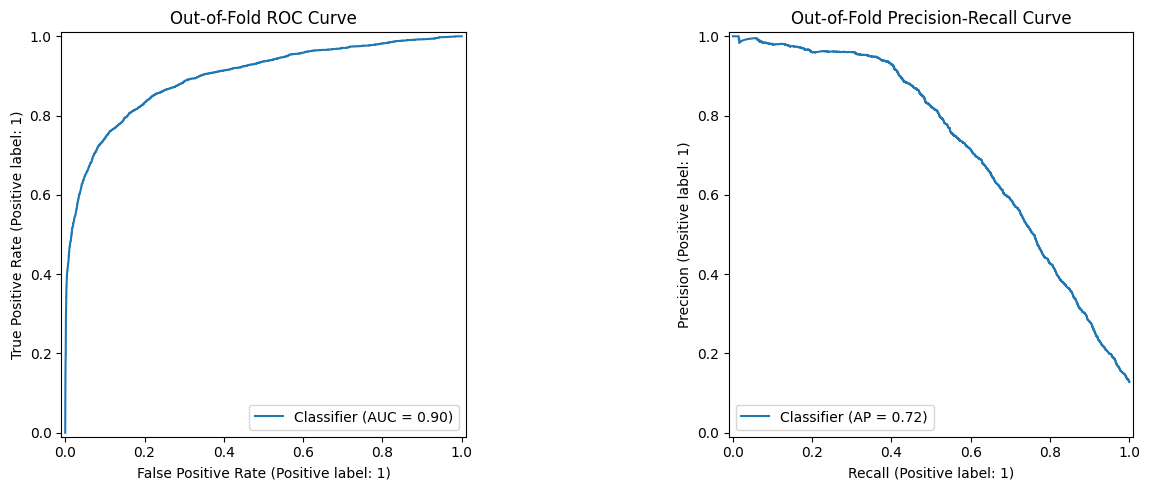

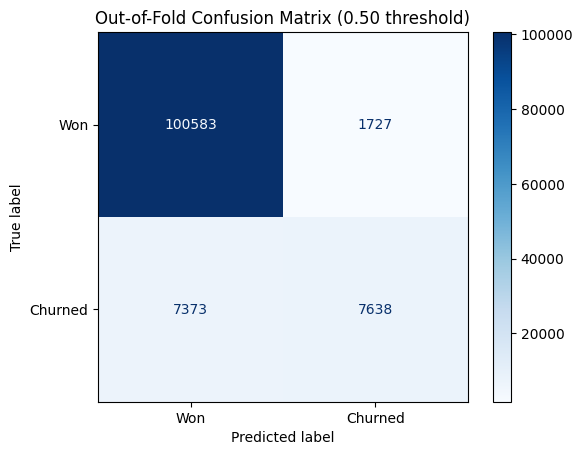

In [6]:
print('Best model by PR-AUC:', best_model_name)
print('\nClassification report (threshold=0.50):')
print(classification_report(y, oof_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, oof_proba, ax=axes[0])
axes[0].set_title('Out-of-Fold ROC Curve')

PrecisionRecallDisplay.from_predictions(y, oof_proba, ax=axes[1])
axes[1].set_title('Out-of-Fold Precision-Recall Curve')

plt.tight_layout()
plt.show()

cm = confusion_matrix(y, oof_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Won', 'Churned'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Out-of-Fold Confusion Matrix (0.50 threshold)')
plt.show()

In [7]:
# Fit best model on full data and save artifacts
best_pipe.fit(X, y)

models_dir = Path('../../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / 'best_churn_model_pipeline.joblib'
results_path = models_dir / 'cv_results_5fold.csv'
summary_path = models_dir / 'best_model_oof_metrics.csv'

joblib.dump(best_pipe, model_path)
results_df.to_csv(results_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f'Saved model: {model_path.resolve()}')
print(f'Saved CV results: {results_path.resolve()}')
print(f'Saved OOF summary: {summary_path.resolve()}')

Saved model: /home/nitin/Desktop/Code/AI/customer-churn-prediction/models/best_churn_model_pipeline.joblib
Saved CV results: /home/nitin/Desktop/Code/AI/customer-churn-prediction/models/cv_results_5fold.csv
Saved OOF summary: /home/nitin/Desktop/Code/AI/customer-churn-prediction/models/best_model_oof_metrics.csv
